In [1]:
import pandas as pd

extract_dir = "/home/akash/Downloads/DR_images"

train_df = pd.read_csv(f"{extract_dir}/train.csv")
test_df  = pd.read_csv(f"{extract_dir}/test.csv")

print(len(train_df), len(test_df))


3662 1928


In [2]:
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import torch

class_names = ['No_DR','Mild','Moderate','Severe','Proliferative']

val_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

class DRDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.root}/{row['id_code']}.png").convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, int(row['diagnosis'])


In [4]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet34(weights=None)

resnet.fc = nn.Sequential(
    nn.Linear(512,256),
    nn.Linear(256,128),
    nn.Linear(128,64),
    nn.Linear(64,5)
)

resnet.load_state_dict(torch.load("resnet34.pth", map_location=device))

resnet.to(device)
resnet.eval()

print("ResNet loaded successfully 🎯")


ResNet loaded successfully 🎯


In [5]:
from torchvision import models
import torch.nn as nn

effnet = models.efficientnet_v2_s(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 5)

effnet.load_state_dict(torch.load("efficientnetv2_dr.pth", map_location=device))
effnet.to(device)
effnet.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [6]:
from torch.utils.data import DataLoader

data_set = DRDataset(train_df, f"{extract_dir}/train_images", transform=val_transform)

train_size = int(len(data_set)*0.9)
valid_size = len(data_set) - train_size

train_set, valid_set = torch.utils.data.random_split(data_set, [train_size, valid_size])

valid_dataloader = DataLoader(valid_set, batch_size=4, shuffle=False)


In [17]:
import torch.nn.functional as F
import torch

correct = 0
total = 0

resnet.eval()
effnet.eval()

with torch.inference_mode():
    for x, y in valid_dataloader:

        x = x.to(device)
        y = y.to(device)

        p1 = F.softmax(resnet(x), dim=1)
        p2 = F.softmax(effnet(x), dim=1)

        avg = (p1 + p2) / 2

        preds = avg.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"\n⭐ Ensemble Accuracy = {100*correct/total:.2f}%")



⭐ Ensemble Accuracy = 98.37%


In [12]:
import pandas as pd

extract_dir = "/home/akash/Downloads/DR_images"   # <-- confirm this path
csv_path = f"{extract_dir}/train.csv"

train_df = pd.read_csv(csv_path)

print(train_df.head())


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [13]:
train_split = train_df[:3000]
valid_split = train_df[3000:]


In [14]:
print(len(valid_split))


662


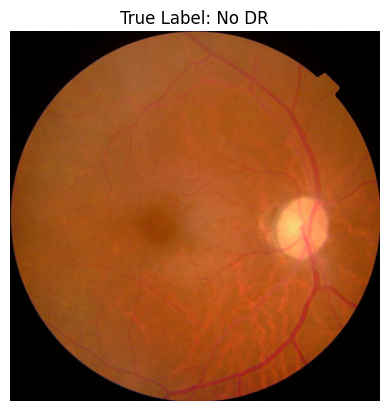

ResNet → No DR
EffNet → No DR
⭐ Ensemble → No DR
--------------------------------------------------


In [16]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
import torch

class_names = ['No DR','Mild','Moderate','Severe','Proliferative']

resnet.eval()
effnet.eval()

samples = valid_split.sample(1).reset_index(drop=True)

for i in range(len(samples)):

    img_id = samples.iloc[i]["id_code"]
    true_label = samples.iloc[i]["diagnosis"]

    img_path = f"{extract_dir}/train_images/{img_id}.png"
    img = Image.open(img_path).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True Label: {class_names[true_label]}")
    plt.show()

    x = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        p1 = F.softmax(resnet(x), dim=1)
        p2 = F.softmax(effnet(x), dim=1)

        ensemble = (p1 + p2) / 2

        pred_res = p1.argmax(1).item()
        pred_eff = p2.argmax(1).item()
        pred_final = ensemble.argmax(1).item()

    print(f"ResNet → {class_names[pred_res]}")
    print(f"EffNet → {class_names[pred_eff]}")
    print(f"⭐ Ensemble → {class_names[pred_final]}")
    print("-"*50)
